In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

raw_path = Path("manufacturing_defect_dataset.csv")
df = pd.read_csv(raw_path)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

In [2]:
df['DefectStatus'].value_counts()


DefectStatus
1    2723
0     517
Name: count, dtype: int64

In [3]:
TARGET = 'DefectStatus'


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(TARGET)   # ✅ REMOVE TARGET FROM NUMERIC FEATURES


In [5]:
# Fill only feature columns, NOT target 
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# If any categorical columns exist 
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")


In [6]:
df.drop_duplicates(inplace=True)


In [7]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [8]:
df['DefectStatus'].value_counts()


DefectStatus
1    2723
0     517
Name: count, dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [10]:
df.isnull().sum()
df.info()
df['DefectStatus'].value_counts()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   float64
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   float64
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   float64
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   float64
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3.240000e+03,3240.000000
mean,-1.315820e-17,-2.368476e-16,2.324615e-15,8.991436e-17,-1.864078e-16,1.836665e-16,-1.244546e-16,1.595432e-16,-7.237009e-17,1.814735e-16,1.694118e-15,-4.166763e-17,-3.651400e-16,1.990178e-16,7.237009e-17,-3.947460e-17,0.840432
std,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,1.000154e+00,0.366261
min,-1.709561e+00,-1.723282e+00,-1.706849e+00,-1.500375e+00,-1.716403e+00,-1.733355e+00,-1.670136e+00,-1.731746e+00,-1.724906e+00,-1.766977e+00,-1.753565e+00,-1.585593e+00,-1.723639e+00,-1.714514e+00,-1.721429e+00,-1.712797e+00,0.000000
25%,-8.634006e-01,-8.576404e-01,-8.620792e-01,-9.140504e-01,-8.787216e-01,-8.639870e-01,-8.333611e-01,-8.568128e-01,-8.742103e-01,-8.570989e-01,-8.492317e-01,-8.949538e-01,-8.674272e-01,-8.530037e-01,-8.636468e-01,-8.988628e-01,1.000000
50%,1.817537e-03,-4.135644e-03,-2.230352e-02,2.585979e-01,-3.079631e-02,1.128682e-02,7.617659e-02,-2.509427e-02,1.170686e-03,3.331290e-02,1.496268e-02,1.410056e-01,7.221244e-03,-1.981377e-02,-1.345892e-02,1.834269e-03,1.000000
75%,8.641770e-01,8.593247e-01,8.607898e-01,8.449221e-01,8.820299e-01,8.802400e-01,8.038067e-01,8.822457e-01,8.716976e-01,8.542058e-01,8.755847e-01,8.316452e-01,8.639064e-01,8.840124e-01,8.733923e-01,8.908652e-01,1.000000
max,1.717008e+00,1.757527e+00,1.763716e+00,1.431246e+00,1.717172e+00,1.710835e+00,1.676963e+00,1.729327e+00,1.708106e+00,1.705953e+00,1.739850e+00,1.522285e+00,1.741680e+00,1.716110e+00,1.742872e+00,1.722791e+00,1.000000


In [11]:
processed_path = Path("cleaned_defect_data.csv")
df.to_csv(processed_path, index=False)


In [12]:
# Note: Before this EDA step, the cleaned dataset was also loaded into a SQLite database (`factory_database.db`) 
# in Phase 1.5, where SQL was used to compute core KPIs such as defect rate, supplier quality impact and downtime–defect correlations.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_defect_data.csv")

df.head()
df['DefectStatus'].value_counts()


DefectStatus
1    2723
0     517
Name: count, dtype: int64

In [14]:
overall_defect_rate = df['DefectStatus'].mean() * 100
overall_defect_rate


84.04320987654322

In [15]:
kpi_comparison = df.groupby('DefectStatus').mean(numeric_only=True).T
kpi_comparison


DefectStatus,0,1
ProductionVolume,-0.295991,0.056198
ProductionCost,-0.061323,0.011643
SupplierQuality,-0.087631,0.016638
DeliveryDelay,-0.012449,0.002364
DefectRate,-0.563981,0.107080
QualityScore,0.457203,-0.086806
MaintenanceHours,-0.681854,0.129460
DowntimePercentage,-0.009474,0.001799
InventoryTurnover,-0.015452,0.002934
StockoutRate,-0.093116,0.017679


<Figure size 1200x600 with 0 Axes>

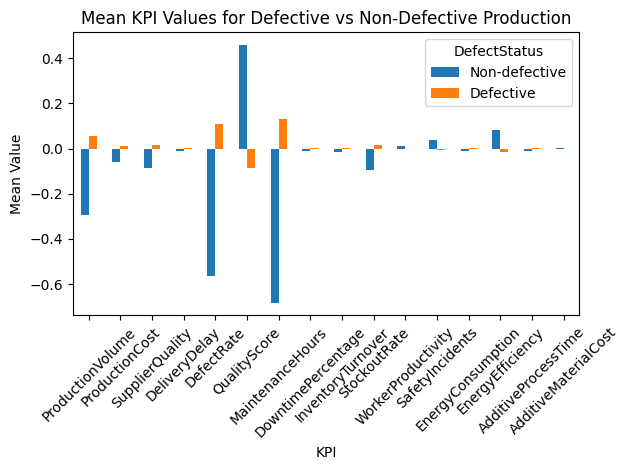

In [16]:
plt.figure(figsize=(12, 6))

# Optional: rename columns for readability
kpi_plot = kpi_comparison.copy()
if 0 in kpi_plot.columns and 1 in kpi_plot.columns:
    kpi_plot = kpi_plot.rename(columns={0: "Non-defective", 1: "Defective"})

kpi_plot.plot(kind='bar')
plt.title("Mean KPI Values for Defective vs Non-Defective Production")
plt.xlabel("KPI")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
kpi_comparison.head()


DefectStatus,0,1
ProductionVolume,-0.295991,0.056198
ProductionCost,-0.061323,0.011643
SupplierQuality,-0.087631,0.016638
DeliveryDelay,-0.012449,0.002364
DefectRate,-0.563981,0.107080


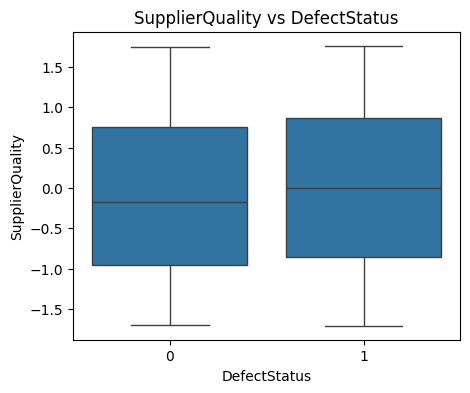

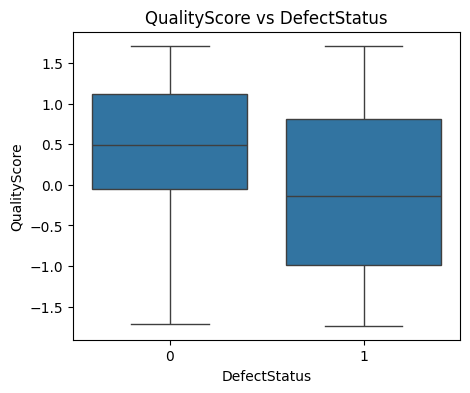

In [58]:
quality_cols = ['SupplierQuality', 'QualityScore']

for col in quality_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='DefectStatus', y=col, data=df)
    plt.title(f"{col} vs DefectStatus")
    plt.show()


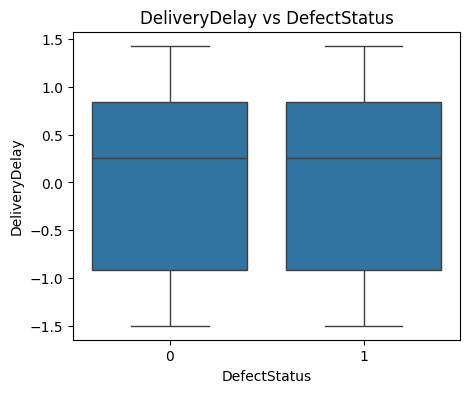

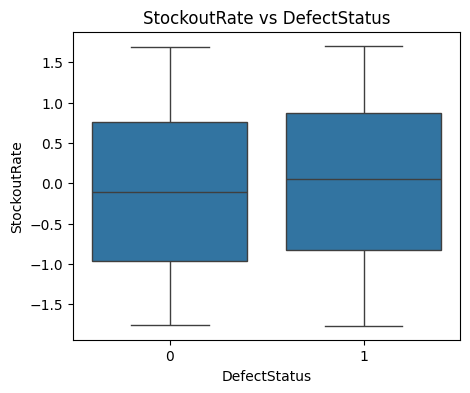

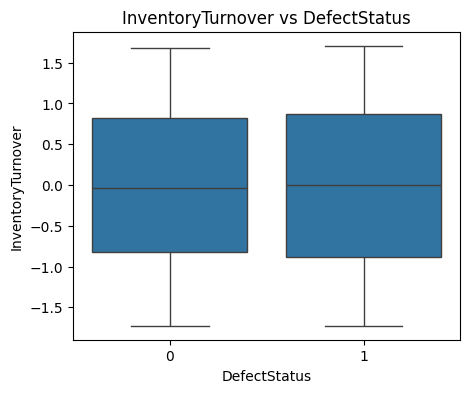

In [60]:
logistics_cols = ['DeliveryDelay', 'StockoutRate', 'InventoryTurnover']

for col in logistics_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='DefectStatus', y=col, data=df)
    plt.title(f"{col} vs DefectStatus")
    plt.show()


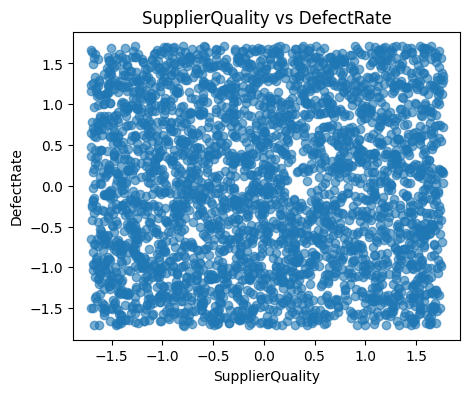

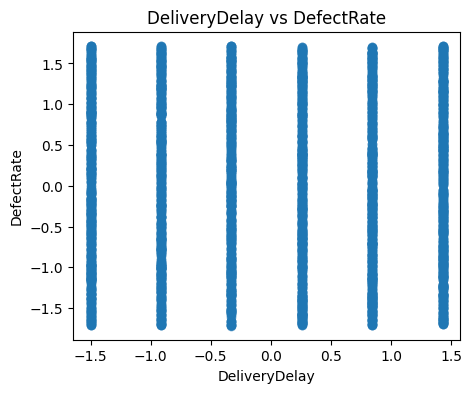

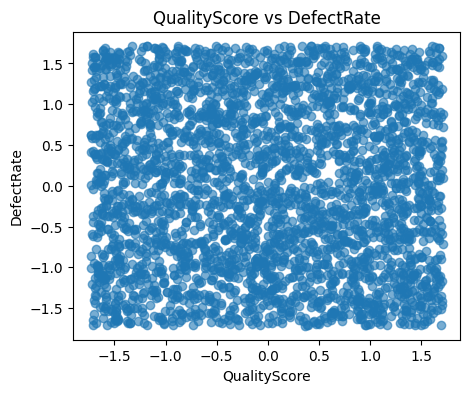

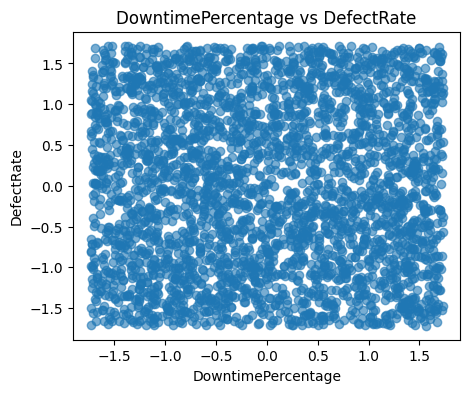

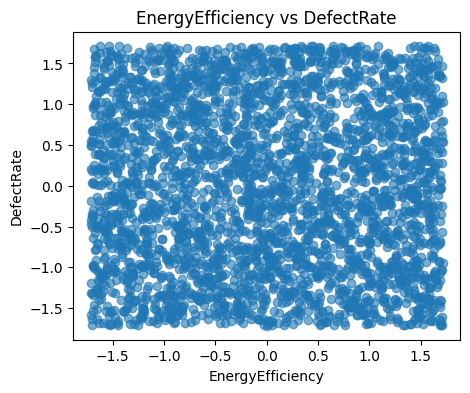

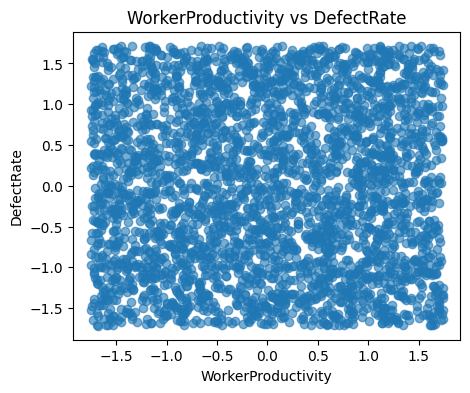

In [62]:
driver_cols = [
    'SupplierQuality', 'DeliveryDelay', 'QualityScore',
    'DowntimePercentage', 'EnergyEfficiency', 'WorkerProductivity'
]

for col in driver_cols:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col], df['DefectRate'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("DefectRate")
    plt.title(f"{col} vs DefectRate")
    plt.show()


In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_defect_data.csv")

df.head()
df['DefectStatus'].value_counts()


DefectStatus
1    2723
0     517
Name: count, dtype: int64

In [20]:
target_col = 'DefectStatus'

# All numeric columns
all_features = df.columns.tolist()

# Remove target and potential leakage column
features = [col for col in all_features if col not in [target_col, 'DefectRate']]

print("Features used for modeling:")
print(features)

X = df[features]
y = df[target_col]


Features used for modeling:
['ProductionVolume', 'ProductionCost', 'SupplierQuality', 'DeliveryDelay', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'InventoryTurnover', 'StockoutRate', 'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption', 'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps same defect ratio in train & test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train shape: (2592, 15)
Test shape: (648, 15)
Train class balance:
 DefectStatus
1    0.840278
0    0.159722
Name: proportion, dtype: float64
Test class balance:
 DefectStatus
1    0.841049
0    0.158951
Name: proportion, dtype: float64


In [22]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # handle class imbalance if present
    solver='lbfgs'
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]  # prob of class 1



===== Logistic Regression Evaluation =====
Accuracy : 0.7067901234567902
Precision: 0.9256594724220624
Recall   : 0.708256880733945
F1-score : 0.8024948024948025
ROC-AUC  : 0.7677741159704286

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.70      0.43       103
           1       0.93      0.71      0.80       545

    accuracy                           0.71       648
   macro avg       0.62      0.70      0.62       648
weighted avg       0.83      0.71      0.74       648



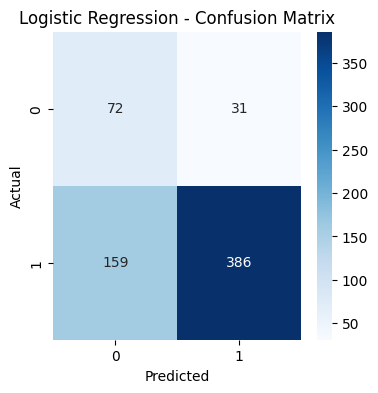

In [23]:
def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    
    if y_prob is not None:
        try:
            print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
        except ValueError:
            print("ROC-AUC  : Could not be computed")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model(y_test, y_pred_lr, y_prob_lr, model_name="Logistic Regression")



===== Random Forest Evaluation =====
Accuracy : 0.8317901234567902
Precision: 0.8732876712328768
Recall   : 0.9357798165137615
F1-score : 0.9034543844109831
ROC-AUC  : 0.7896143226151242

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.28      0.35       103
           1       0.87      0.94      0.90       545

    accuracy                           0.83       648
   macro avg       0.66      0.61      0.63       648
weighted avg       0.81      0.83      0.82       648



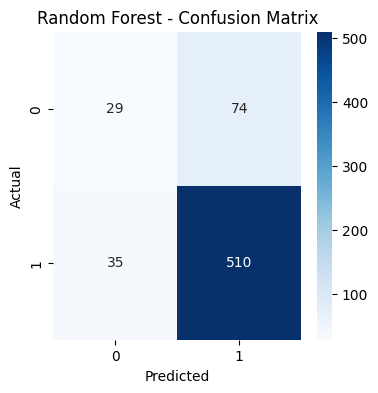

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_rf, y_prob_rf, model_name="Random Forest")


In [25]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df


,Feature,Importance
5,MaintenanceHours,0.254685
4,QualityScore,0.165688
0,ProductionVolume,0.112143
8,StockoutRate,0.049551
14,AdditiveMaterialCost,0.047959
11,EnergyConsumption,0.046395
12,EnergyEfficiency,0.043034
2,SupplierQuality,0.042588
7,InventoryTurnover,0.041961
9,WorkerProductivity,0.040566


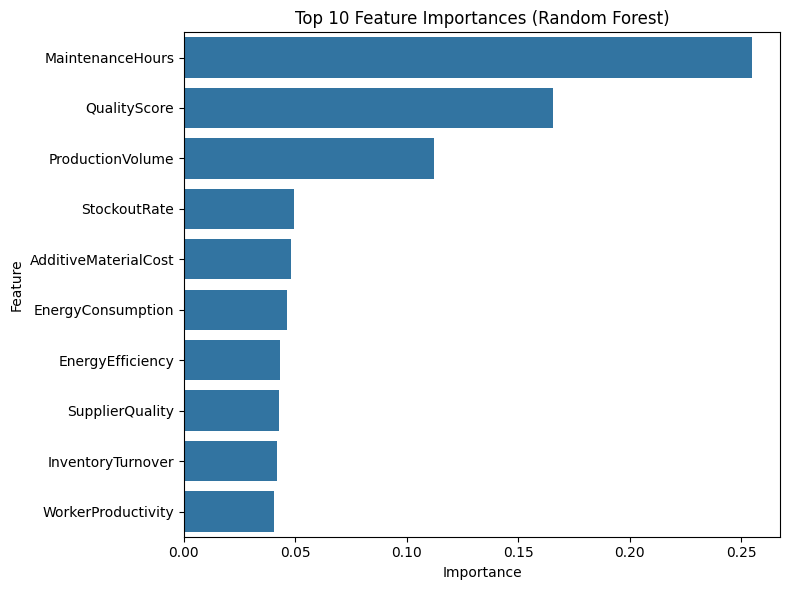

In [26]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [27]:
import joblib
from pathlib import Path

# Create the models directory if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(rf, models_dir / "defect_prediction_random_forest.pkl")
joblib.dump(log_reg, models_dir / "defect_prediction_logreg.pkl")

print("Models saved successfully in the 'models/' directory.")


Models saved successfully in the 'models/' directory.


In [28]:
df['PredictedDefect'] = rf.predict(X)
df.to_csv("defect_predictions.csv", index=False)
